# Surface Temperature (Part 1) - Climatology

## Global Inset

### Global Importation

In [1]:
# Shape modules 
from collections import defaultdict

# Computational modules 
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


### Load Raw Data (ESM-piCTL)

In [2]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-piCTL'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_0 = ["tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_210001-214912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_215001-224912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_225001-234912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_235001-244912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_245001-250012.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_250101-254912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_255001-264912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_265001-274912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_275001-279912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_280001-280012.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_280101-284912.nc",
               "tas_Amon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_285001-289912.nc"]

files_ens_0 = {}
for expe in tqdm(file_list_0):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_0[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|███████████████████████████| 12/12 [00:04<00:00,  2.65it/s]


### Load Raw Data (ESM-up2p0)

In [3]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-up2p0'
config_1 = 'r1i1p1f1'
var = 'tas'
sub1 = 'gn'
sub2 = 'v20241216'
file_list_1 = ["tas_Amon_UKESM1-2-LL_esm-up2p0_r1i1p1f1_gn_185001-194912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r1i1p1f1_gn_195001-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r1i1p1f1_gn_205001-213912.nc"]

files_ens_1 = {}
for expe in tqdm(file_list_1):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{sub1}/{sub2}/{expe}")
    files_ens_1[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 11.15it/s]


In [4]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20250108'
file_list_2 = ["tas_Amon_UKESM1-2-LL_esm-up2p0_r2i1p1f1_gn_185001-194912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r2i1p1f1_gn_195001-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r2i1p1f1_gn_205001-213912.nc"]

files_ens_2 = {}
for expe in tqdm(file_list_2):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}")
    files_ens_2[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 11.42it/s]


In [5]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20250107'
file_list_3 = ["tas_Amon_UKESM1-2-LL_esm-up2p0_r3i1p1f1_gn_185001-194912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r3i1p1f1_gn_195001-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r3i1p1f1_gn_205001-213912.nc"]

files_ens_3 = {}
for expe in tqdm(file_list_3):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}")
    files_ens_3[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 11.03it/s]


In [6]:
config_4 = 'r4i1p1f1'
sub5 = 'v20250107'
file_list_4 = ["tas_Amon_UKESM1-2-LL_esm-up2p0_r4i1p1f1_gn_185001-194912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r4i1p1f1_gn_195001-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0_r4i1p1f1_gn_205001-213912.nc"]

files_ens_4 = {}
for expe in tqdm(file_list_4):
    path_tmp = (f"{path}{esm_var}/{config_4}/{Table_ID}/{var}/{sub1}/{sub5}/{expe}")
    files_ens_4[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 3/3 [00:00<00:00, 10.28it/s]


### Load Raw Data (Branch-Runs)

In [7]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl2p0'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_5 = ["tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_194401-194912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_195001-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_205001-214912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_215001-224912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_225001-234312.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_234401-234912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_gn_235001-244412.nc"]

files_ens_5 = {}
for expe in tqdm(file_list_5):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_5[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 7/7 [00:00<00:00, 12.48it/s]


In [8]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl3p0'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_6 = ["tas_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_199201-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_205001-214912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_215001-224912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_225001-234912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_gn_235001-241112.nc"]

files_ens_6 = {}
for expe in tqdm(file_list_6):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_6[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 5/5 [00:00<00:00, 16.37it/s]


In [9]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl4p0'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_7 = ["tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_204401-204912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_205001-214912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_215001-224912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_225001-234312.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_234401-234912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_235001-244912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_gn_245001-254412.nc"]

files_ens_7 = {}
for expe in tqdm(file_list_7):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_7[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 7/7 [00:00<00:00, 16.99it/s]


In [10]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl5p0'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_8 = ["tas_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_208201-209212.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_209301-214912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_215001-224912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_225001-234912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1_gn_235001-239412.nc"]

files_ens_8 = {}
for expe in tqdm(file_list_8):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_8[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 5/5 [00:00<00:00, 15.25it/s]


In [11]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl6p0'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_9 = ["tas_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_213701-214912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_215001-224912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_225001-234912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_235001-244912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_245001-254912.nc",
               "tas_Amon_UKESM1-2-LL_esm-up2p0-gwl6p0_r1i1p1f1_gn_255001-263912.nc"]

files_ens_9 = {}
for expe in tqdm(file_list_9):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_9[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 6/6 [00:00<00:00, 15.81it/s]


In [12]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-swl1p5'
config_1 = 'r1i1p1f1'
var = 'tas'
file_list_10 = ["tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_191901-194912.nc",
                "tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_195001-204912.nc",
                "tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_205001-214912.nc",
                "tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_215001-224912.nc",
                "tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_225001-234912.nc",
                "tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_235001-244912.nc",
                "tas_Amon_UKESM1-0-LL_esm-swl1p5_r1i1p1f2_gn_245001-245612.nc"]

files_ens_10 = {}
for expe in tqdm(file_list_10):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{expe}")
    files_ens_10[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 7/7 [00:00<00:00, 16.36it/s]


### Merge Data

In [13]:
# Merge files of the same ensemble together.
# Implementation
model_short = 'UKESM_ramp_up'
path_figure = f"/home/users/alvin_ch/figures/Multi-model/{model_short}/Surface_Temp/"
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Surface_Temp/"

def files_merge(files_dict, file_list, branch_level):

    assert len(files_dict) == len(file_list)

    ds = []
    
    for i in range(len(file_list)):
        ds.append(files_dict[file_list[i]])

    merged = xr.concat(ds, dim="time")
    merged = merged.compute()
    
    merged.to_netcdf(f"{path_files}/{branch_level}_time_merged.nc")
    merged.close()

In [14]:
"""
# piCTL
files_merge(files_ens_0, file_list_0, 'esm-piCTL')

# Ramp-up
files_merge(files_ens_1, file_list_1, 'esm-up2p0_r1i1p1f1')
files_merge(files_ens_2, file_list_2, 'esm-up2p0_r2i1p1f1')
files_merge(files_ens_3, file_list_3, 'esm-up2p0_r3i1p1f1')
files_merge(files_ens_4, file_list_4, 'esm-up2p0_r4i1p1f1')

# 1.5-degree
files_merge(files_ens_10, file_list_10, 'esm-swl1p5')

# 2-degree
files_merge(files_ens_5, file_list_5, 'esm-swl2p0')

# 3-degree
files_merge(files_ens_6, file_list_6, 'esm-swl3p0')

# 4-degree
files_merge(files_ens_7, file_list_7, 'esm-swl4p0')

# 5-degree
files_merge(files_ens_8, file_list_8, 'esm-swl5p0')

# 6-degree
files_merge(files_ens_9, file_list_9, 'esm-swl6p0')
"""

"\n# piCTL\nfiles_merge(files_ens_0, file_list_0, 'esm-piCTL')\n\n# Ramp-up\nfiles_merge(files_ens_1, file_list_1, 'esm-up2p0_r1i1p1f1')\nfiles_merge(files_ens_2, file_list_2, 'esm-up2p0_r2i1p1f1')\nfiles_merge(files_ens_3, file_list_3, 'esm-up2p0_r3i1p1f1')\nfiles_merge(files_ens_4, file_list_4, 'esm-up2p0_r4i1p1f1')\n\n# 1.5-degree\nfiles_merge(files_ens_10, file_list_10, 'esm-swl1p5')\n\n# 2-degree\nfiles_merge(files_ens_5, file_list_5, 'esm-swl2p0')\n\n# 3-degree\nfiles_merge(files_ens_6, file_list_6, 'esm-swl3p0')\n\n# 4-degree\nfiles_merge(files_ens_7, file_list_7, 'esm-swl4p0')\n\n# 5-degree\nfiles_merge(files_ens_8, file_list_8, 'esm-swl5p0')\n\n# 6-degree\nfiles_merge(files_ens_9, file_list_9, 'esm-swl6p0')\n"

### Load Merged piCTL Data

In [15]:
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Surface_Temp/"
filename = "time_merged.nc"
controlled = ['esm-piCTL']

controlled_run_file = {}

for ens in controlled:
    controlled_run_file[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

In [16]:
controlled_run_file[controlled[0]]['tas'].values[:1]

array([[[248.58154, 248.594  , 248.60889, ..., 248.55786, 248.54468,
         248.54956],
        [249.70532, 249.66797, 249.66577, ..., 249.67969, 249.68384,
         249.66113],
        [249.79956, 249.69531, 249.73755, ..., 249.75562, 249.72656,
         249.77905],
        ...,
        [241.73242, 241.78345, 241.86255, ..., 241.41528, 241.50195,
         241.61499],
        [240.23926, 240.30273, 240.28296, ..., 240.2002 , 240.22412,
         240.22095],
        [239.02515, 239.04541, 239.0437 , ..., 238.96606, 238.95728,
         239.00464]]], shape=(1, 144, 192), dtype=float32)

### Load Merged Ramp-Up Data (up2p0)

In [17]:
members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

ramp_up_model_files = {}

for ens in members:
    ramp_up_model_files[ens] = xr.open_mfdataset(f'{path_files}esm-up2p0_{ens}_{filename}', combine='by_coords', use_cftime=True)

In [18]:
# Data quality check.
ramp_up_model_files[members[0]]

<xarray.Dataset> Size: 404MB
Dimensions:    (time: 3480, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 28kB 1850-01-16 00:00:00 ... 2139-12-16 00:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 56kB dask.array<chunksize=(3480, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 8MB dask.array<chunksize=(3480, 144, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 11MB dask.array<chunksize=(3480, 192, 1), meta=np.ndarray>
    tas        (time, lat, lon) float32 385MB dask.array<chunksize=(1160, 48, 64), meta=np.ndarray>
Attributes: (12/41)
    forcing_index:          1
    initialization_index:   1
    physics_index:          1
    realization_index:      1
    license:                GCModelDev model data is licensed under the Open ...
    Conventions:            CF-1.7 CMIP-6.2
    ...                     ...
    variable_id:            tas
    variable_name:          tas
    variant_label:          r1i1p1f1
    cmor_version:           3.7.3
    parent_time_units:      days since 1850-01-01
    branch_time_in_parent:  153720.0

### Load Merged Branch-Run Data (esm-swl)

In [19]:
ensemble = 'r1i1p1f1'
level_list = ["esm-swl1p5", "esm-swl2p0", "esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

level_run_model_1_files = {}

for scenario in level_list:
    level_run_model_1_files[scenario] = xr.open_mfdataset(f'{path_files}{scenario}_{filename}', combine='by_coords', use_cftime=True)
    print(f'\n{scenario} Branch Off Start Date: ', level_run_model_1_files[scenario]['time'].min().item())
    print(f'{scenario} Branch Off End Date: ', level_run_model_1_files[scenario]['time'].max().item())


esm-swl1p5 Branch Off Start Date:  1919-01-16 00:00:00
esm-swl1p5 Branch Off End Date:  2456-12-16 00:00:00

esm-swl2p0 Branch Off Start Date:  1944-01-16 00:00:00
esm-swl2p0 Branch Off End Date:  2444-12-16 00:00:00

esm-swl3p0 Branch Off Start Date:  1992-01-16 00:00:00
esm-swl3p0 Branch Off End Date:  2411-12-16 00:00:00

esm-swl4p0 Branch Off Start Date:  2044-01-16 00:00:00
esm-swl4p0 Branch Off End Date:  2544-12-16 00:00:00

esm-swl5p0 Branch Off Start Date:  2082-01-16 00:00:00
esm-swl5p0 Branch Off End Date:  2394-12-16 00:00:00

esm-swl6p0 Branch Off Start Date:  2137-01-16 00:00:00
esm-swl6p0 Branch Off End Date:  2639-12-16 00:00:00


## Overview Time Series

### Land-Sea Mask

In [20]:
path_mask = "/home/users/speatier/DATA/TIPMIP/UKESM1-0-LL/sftlf_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc"
file_mask = xr.open_mfdataset(path_mask, combine='by_coords')
file_mask

<xarray.Dataset> Size: 119kB
Dimensions:   (lat: 144, bnds: 2, lon: 192)
Coordinates:
  * lat       (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon       (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    type      |S4 4B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds  (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    sftlf     (lat, lon) float32 111kB dask.array<chunksize=(144, 192), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   39600.0
    branch_time_in_parent:  39600.0
    creation_date:          2019-07-04T21:31:24Z
    ...                     ...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/4a2f7b6f-f63b-4f19-895d-0342b776c5de
    variable_id:            sftlf
    variant_label:          r1i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0

In [21]:
# Create a boolean mask where land = True (i.e., land fraction < threshold)
land_masked = file_mask['sftlf'] < 50   # threshold: less than 50% land = ocean
ocean_masked = file_mask['sftlf'] > 50  # threshold: more than 50% land = land

### Standardise Coordinates

In [22]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

In [23]:
ocean_masked = standardise_coordinates(ocean_masked)

### Implementation 1a (Seasonal Mean, Over Time)

In [24]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

### Implementation 1b (Regional Seasonal Mean, Over Time)

In [25]:
def seasonal_area_weighted_avg(data, lonmin, lonmax, latmin, latmax):

    # Standardise coordinates
    data = standardise_coordinates(data)
    
    # 1. Spatial filter
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax))

    # 2. Masking the ocean.
    data = data.where(ocean_masked)
    
    # 3. Seasonal average (MJJAS)
    data = data.sel(time=data.time.dt.month.isin([5, 6, 7, 8, 9]))
    seasonal = data.groupby('time.year').mean('time')

    # 4. Area-weighted average
    lat_rad = np.radians(seasonal['latitude'])
    lat_weights = np.cos(lat_rad)

    # Broadcast latitude weights over the spatial dimensions
    weights = lat_weights.broadcast_like(seasonal)

    # Account for NaNs / land-sea mask
    valid_mask = ~np.isnan(seasonal)
    weights_masked = weights.where(valid_mask)

    # Normalise weights for each year
    weights_sum = weights_masked.sum(dim=['latitude', 'longitude'])

    # Area-weighted mean
    weighted_avg = ((seasonal * weights_masked).sum(dim=['latitude', 'longitude']) / weights_sum)
    return weighted_avg - 273.15

## Time Series

### Compute Ramp-up Ensemble Mean

In [26]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='tas'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [27]:
time_series_ramp_up_ens_avg = compute_ensemble_mean(members, ramp_up_model_files)
time_series_ramp_up_ens_avg

<xarray.DataArray 'tas' (time: 3480, lat: 144, lon: 192)> Size: 385MB
dask.array<mean_agg-aggregate, shape=(3480, 144, 192), dtype=float32, chunksize=(1160, 48, 64), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 28kB 1850-01-16 00:00:00 ... 2139-12-16 00:00:00
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5

### Overall Regional Seasonal Average Time Series

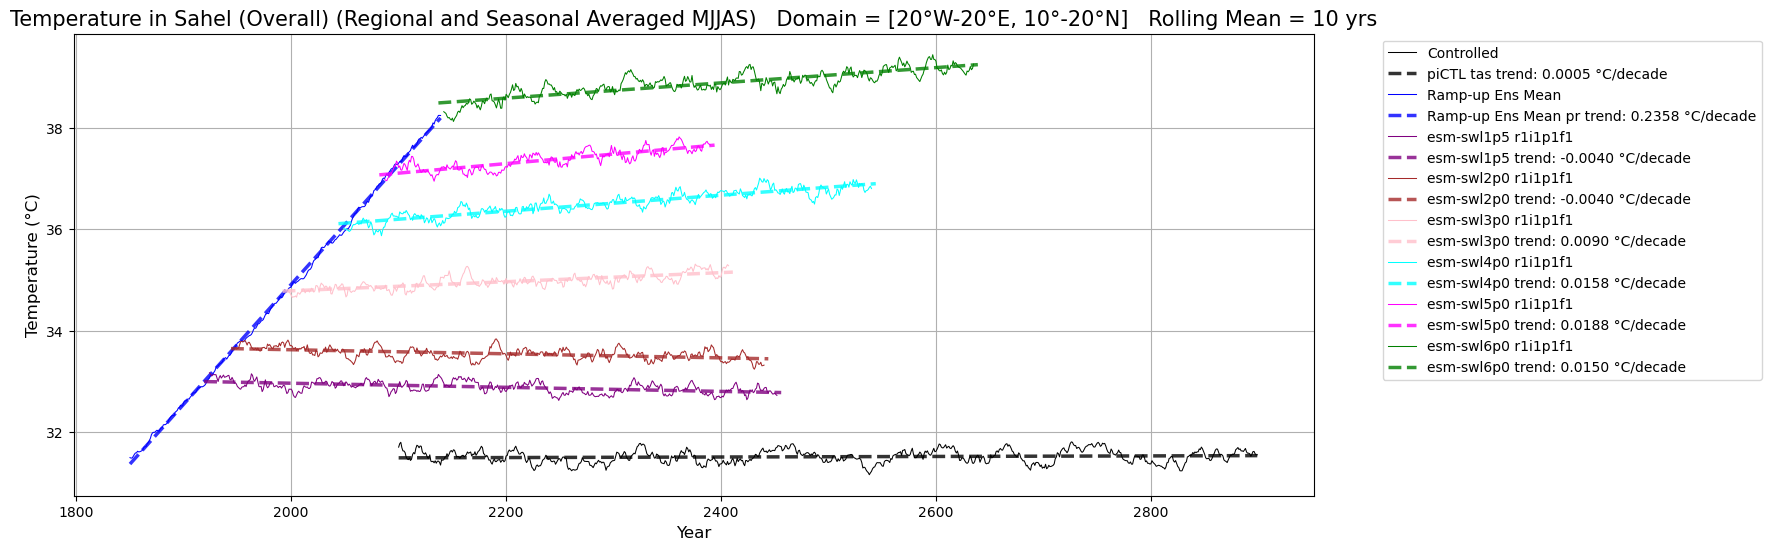

In [28]:
# Parameters
lonmin = -20
lonmax = 20
latmin = 10
latmax = 20

colours = {'controlled': 'black', 'r1i1p1f1': 'blue'}

scenario_colours = {level_list[0]: 'purple', level_list[1]: 'brown', level_list[2]: 'pink',
                    level_list[3]: 'cyan', level_list[4]: 'magenta', level_list[5]: 'green'}

# Set up figure.
fig, ax = plt.subplots(figsize=(16, 6))

### piCTL ###
controlled_pr = seasonal_area_weighted_avg(controlled_run_file[controlled[0]]['tas'],
                                           lonmin, lonmax, latmin, latmax)

years = controlled_pr['year'].values
values = controlled_pr.values
y_smooth = pd.Series(values).rolling(10, center=True, min_periods=1).mean().values
ax.plot(years, y_smooth, label='Controlled', color=colours['controlled'], linewidth=0.75)

# Trend Line
coeffs = np.polyfit(years, values, 1)
trend = np.poly1d(coeffs)(years)
slope_per_decade = coeffs[0]*10

ax.plot(years, trend, linestyle='--',
        label=f'piCTL tas trend: {slope_per_decade:.4f} °C/decade',
        color=colours['controlled'], linewidth=2.5, alpha=0.8)


### Ramp-Up Run ###
# We are using the ensemble mean here.
ramp_up_pr = seasonal_area_weighted_avg(time_series_ramp_up_ens_avg,
                                        lonmin, lonmax, latmin, latmax)

years = ramp_up_pr['year'].values
values = ramp_up_pr.values
y_smooth = pd.Series(values).rolling(10, center=True, min_periods=1).mean().values
colour = colours[members[0]]
ax.plot(years, y_smooth, label=f'Ramp-up Ens Mean', color=colour, linewidth=0.75)

# Trend line
coeffs = np.polyfit(years, values, 1)
slope_per_decade = coeffs[0] * 10
trend = np.poly1d(coeffs)(years)
ax.plot(years, trend, linestyle='--',
        label=f'Ramp-up Ens Mean pr trend: {slope_per_decade:.4f} °C/decade',
        color=colour, linewidth=2.5, alpha=0.8)


### Level Runs ###
for scenario in level_list:
    level_pr = seasonal_area_weighted_avg(level_run_model_1_files[scenario]['tas'],
                                          lonmin, lonmax, latmin, latmax)

    years = level_pr['year'].values
    values = level_pr.values
    y_smooth = pd.Series(values).rolling(10, center=True, min_periods=10).mean().values
    colour = scenario_colours[scenario]
    ax.plot(years, y_smooth, label=f'{scenario} {members[0]}', color=colour, linewidth=0.75)

    coeffs = np.polyfit(years, values, 1)
    trend = np.poly1d(coeffs)(years)
    slope_per_decade = coeffs[0] * 10
    ax.plot(years, trend, linestyle='--',
            label=f'{scenario} trend: {slope_per_decade:.4f} °C/decade', color=colour,
            linewidth=2.5, alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature in Sahel (Overall) (Regional and Seasonal Averaged MJJAS)   Domain = [20°W-20°E, 10°-20°N]   Rolling Mean = 10 yrs', fontsize=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid()

filename = f'{path_figure}time_series_tas_overall_sahel_reg_seas_avg.png'
plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()

### Central Sahel Regional Seasonal Average

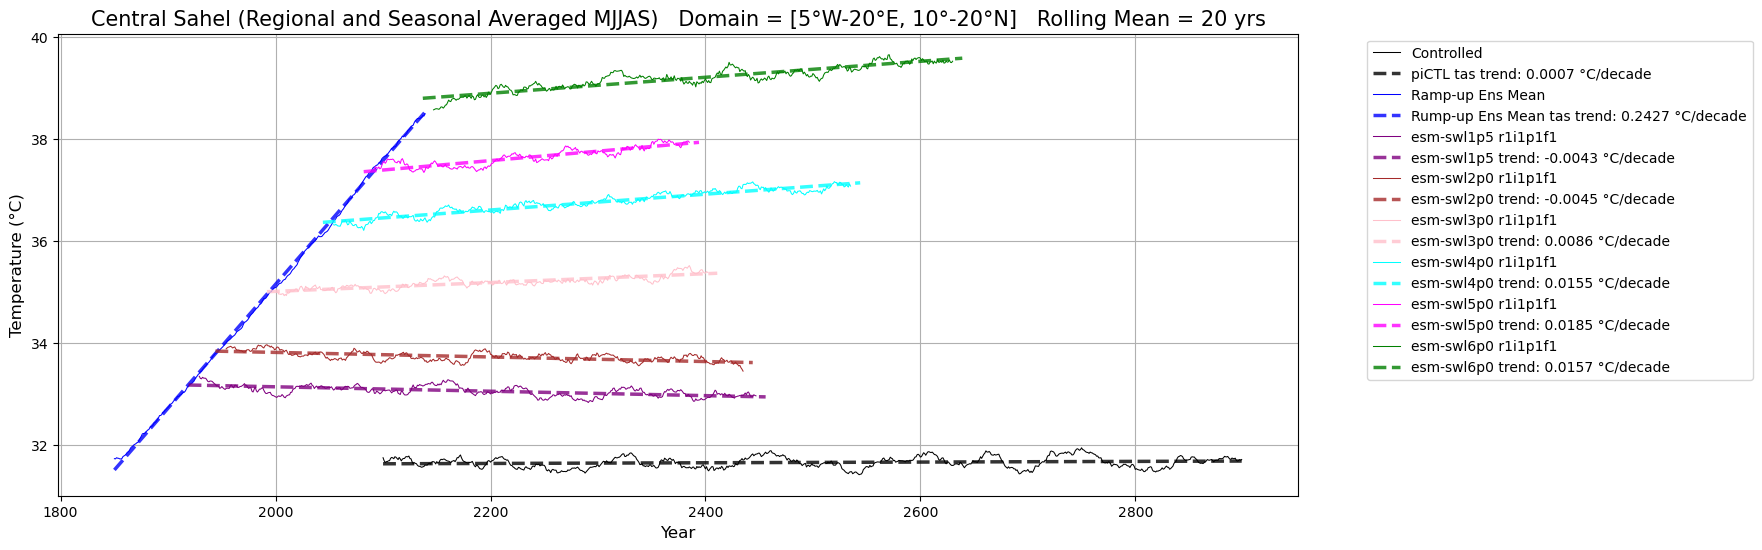

In [29]:
# Parameters
lonmin = -5
lonmax = 20
latmin = 10
latmax = 20

rolling_window = 20

colours = {'controlled': 'black', 'r1i1p1f1': 'blue'}

scenario_colours = {level_list[0]: 'purple', level_list[1]: 'brown', level_list[2]: 'pink',
                    level_list[3]: 'cyan', level_list[4]: 'magenta', level_list[5]: 'green'}

# Set up figure.
fig, ax = plt.subplots(figsize=(16, 6))

### piCTL ###
controlled_pr = seasonal_area_weighted_avg(controlled_run_file[controlled[0]]['tas'],
                                           lonmin, lonmax, latmin, latmax)

years = controlled_pr['year'].values
values = controlled_pr.values
y_smooth = pd.Series(values).rolling(20, center=True, min_periods=0).mean().values
ax.plot(years, y_smooth, label='Controlled', color=colours['controlled'], linewidth=0.75)

# Trend Line
coeffs = np.polyfit(years, values, 1)
trend = np.poly1d(coeffs)(years)
slope_per_decade = coeffs[0]*10

ax.plot(years, trend, linestyle='--',
        label=f'piCTL tas trend: {slope_per_decade:.4f} °C/decade',
        color=colours['controlled'], linewidth=2.5, alpha=0.8)


### Ramp-Up Run ###
ramp_up_pr = seasonal_area_weighted_avg(time_series_ramp_up_ens_avg,
                                        lonmin, lonmax, latmin, latmax)

years = ramp_up_pr['year'].values
values = ramp_up_pr.values
y_smooth = pd.Series(values).rolling(20, center=True, min_periods=0).mean().values
colour = colours[members[0]]
ax.plot(years, y_smooth, label=f'Ramp-up Ens Mean', color=colour, linewidth=0.75)

# Trend line
coeffs = np.polyfit(years, values, 1)
slope_per_decade = coeffs[0] * 10
trend = np.poly1d(coeffs)(years)
ax.plot(years, trend, linestyle='--',
        label=f'Rump-up Ens Mean tas trend: {slope_per_decade:.4f} °C/decade',
        color=colour, linewidth=2.5, alpha=0.8)


### Level Runs ###
for scenario in level_list:
    level_pr = seasonal_area_weighted_avg(level_run_model_1_files[scenario]['tas'],
                                          lonmin, lonmax, latmin, latmax)

    years = level_pr['year'].values
    values = level_pr.values
    y_smooth = pd.Series(values).rolling(20, center=True, min_periods=20).mean().values
    colour = scenario_colours[scenario]
    ax.plot(years, y_smooth, label=f'{scenario} {members[0]}', color=colour, linewidth=0.75)

    coeffs = np.polyfit(years, values, 1)
    trend = np.poly1d(coeffs)(years)
    slope_per_decade = coeffs[0] * 10
    ax.plot(years, trend, linestyle='--',
            label=f'{scenario} trend: {slope_per_decade:.4f} °C/decade', color=colour,
            linewidth=2.5, alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Central Sahel (Regional and Seasonal Averaged MJJAS)   Domain = [5°W-20°E, 10°-20°N]   Rolling Mean = 20 yrs', fontsize=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid()

filename = f'{path_figure}time_series_tas_central_sahel_reg_seas_avg.png'
plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()

### Western Sahel Regional Seasonal Average

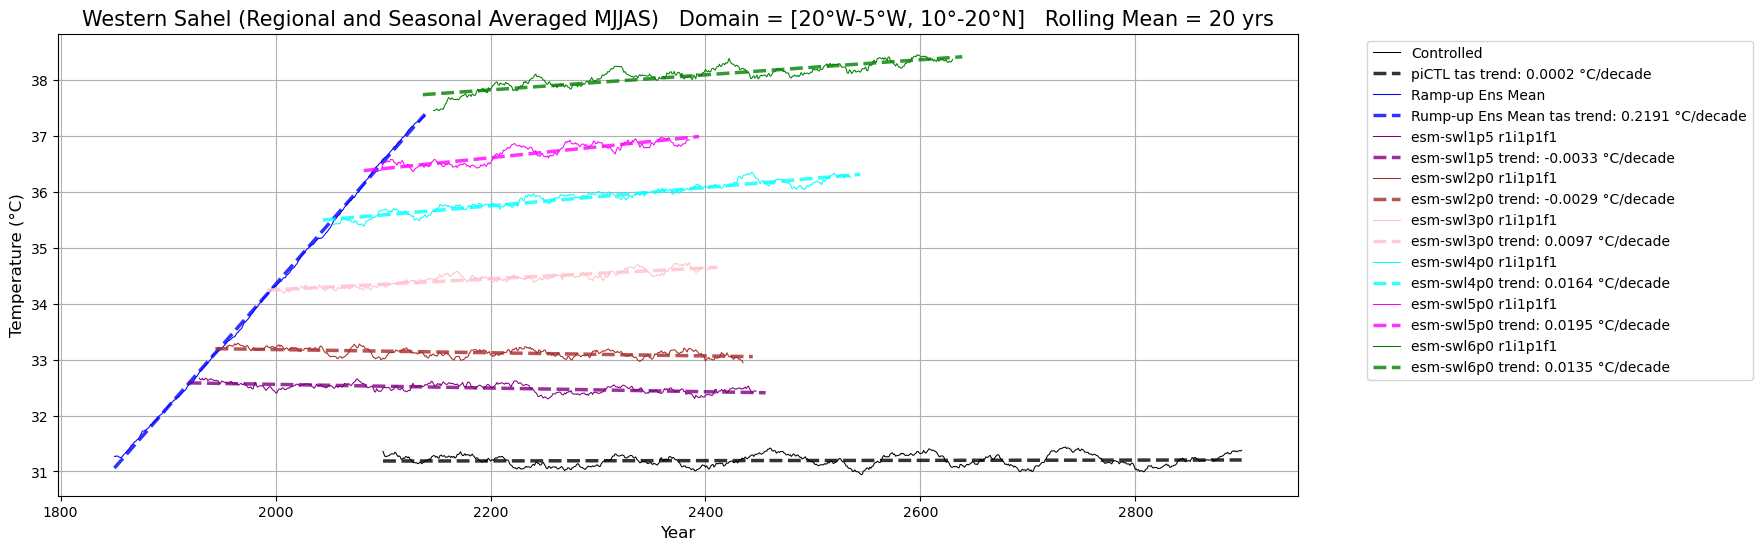

In [30]:
# Parameters
lonmin = -20
lonmax = -5
latmin = 10
latmax = 20

rolling_window = 20

colours = {'controlled': 'black', 'r1i1p1f1': 'blue'}

scenario_colours = {level_list[0]: 'purple', level_list[1]: 'brown', level_list[2]: 'pink',
                    level_list[3]: 'cyan', level_list[4]: 'magenta', level_list[5]: 'green'}

# Set up figure.
fig, ax = plt.subplots(figsize=(16, 6))

### piCTL ###
controlled_pr = seasonal_area_weighted_avg(controlled_run_file[controlled[0]]['tas'],
                                           lonmin, lonmax, latmin, latmax)

years = controlled_pr['year'].values
values = controlled_pr.values
y_smooth = pd.Series(values).rolling(20, center=True, min_periods=0).mean().values
ax.plot(years, y_smooth, label='Controlled', color=colours['controlled'], linewidth=0.75)

# Trend Line
coeffs = np.polyfit(years, values, 1)
trend = np.poly1d(coeffs)(years)
slope_per_decade = coeffs[0]*10

ax.plot(years, trend, linestyle='--',
        label=f'piCTL tas trend: {slope_per_decade:.4f} °C/decade',
        color=colours['controlled'], linewidth=2.5, alpha=0.8)


### Ramp-Up Run ###
ramp_up_pr = seasonal_area_weighted_avg(time_series_ramp_up_ens_avg,
                                        lonmin, lonmax, latmin, latmax)

years = ramp_up_pr['year'].values
values = ramp_up_pr.values
y_smooth = pd.Series(values).rolling(20, center=True, min_periods=0).mean().values
colour = colours[members[0]]
ax.plot(years, y_smooth, label=f'Ramp-up Ens Mean', color=colour, linewidth=0.75)

# Trend line
coeffs = np.polyfit(years, values, 1)
slope_per_decade = coeffs[0] * 10
trend = np.poly1d(coeffs)(years)
ax.plot(years, trend, linestyle='--',
        label=f'Rump-up Ens Mean tas trend: {slope_per_decade:.4f} °C/decade',
        color=colour, linewidth=2.5, alpha=0.8)


### Level Runs ###
for scenario in level_list:
    level_pr = seasonal_area_weighted_avg(level_run_model_1_files[scenario]['tas'],
                                          lonmin, lonmax, latmin, latmax)

    years = level_pr['year'].values
    values = level_pr.values
    y_smooth = pd.Series(values).rolling(20, center=True, min_periods=20).mean().values
    colour = scenario_colours[scenario]
    ax.plot(years, y_smooth, label=f'{scenario} {members[0]}', color=colour, linewidth=0.75)

    coeffs = np.polyfit(years, values, 1)
    trend = np.poly1d(coeffs)(years)
    slope_per_decade = coeffs[0] * 10
    ax.plot(years, trend, linestyle='--',
            label=f'{scenario} trend: {slope_per_decade:.4f} °C/decade', color=colour,
            linewidth=2.5, alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Western Sahel (Regional and Seasonal Averaged MJJAS)   Domain = [20°W-5°W, 10°-20°N]   Rolling Mean = 20 yrs', fontsize=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid()

filename = f'{path_figure}time_series_tas_western_sahel_reg_seas_avg.png'
plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()

### Final Figure

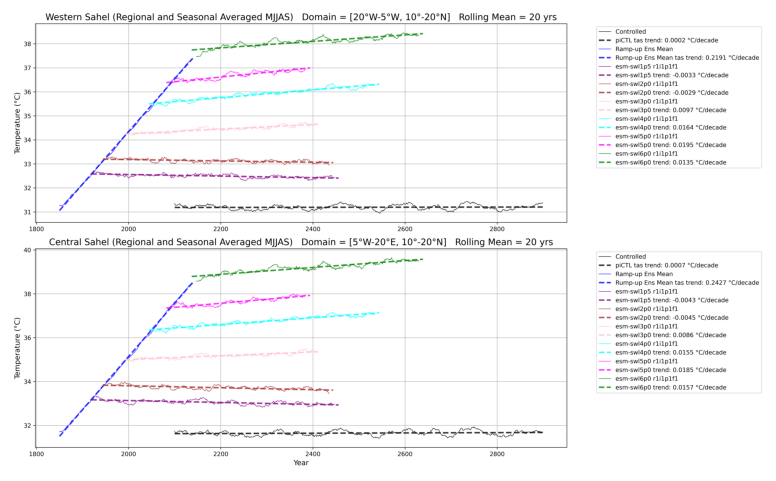

In [31]:
import matplotlib.image as mpimg

fig = plt.figure(figsize=(18, 15))

# Western Sahel
ax1 = fig.add_axes([0.05, 0.55, 0.42, 0.40])   # [left, bottom, width, height]
ax1.imshow(mpimg.imread(f'{path_figure}time_series_tas_western_sahel_reg_seas_avg.png'))
ax1.axis("off")

# Central Sahel
ax2 = fig.add_axes([0.05, 0.40, 0.42, 0.40])
ax2.imshow(mpimg.imread(f'{path_figure}time_series_tas_central_sahel_reg_seas_avg.png'))
ax2.axis("off")

plt.savefig(f"{path_figure}time_series_summarised_regional_seasonal_average.png", bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()

## Climatology and Differences

### Filter Ensemble Data (Climatology)

In [32]:
# Now we are interested in the plus-or-minus 15 years relative to the branch-off point.
# Period varies with level.
# We are only looking at ensemble r1p1i1f1 due to data incompleteness.
ramp_up_filtered_files_ens1 = {}
ramp_up_filtered_files_ens2 = {}
ramp_up_filtered_files_ens3 = {}
ramp_up_filtered_files_ens4 = {}

start_date_list = ["1904-01-01", "1929-01-01", "1977-01-01", "2029-01-01", "2077-01-01", "2129-01-01"]
end_date_list = ["1935-01-01", "1960-01-01", "2008-01-01", "2060-01-01", "2108-01-01", "2160-01-01"]

# Convert units within the loop when saving the file.
for ens in members:
    for (start, end, scenario) in zip(start_date_list, end_date_list, level_list):
        if ens == 'r1i1p1f1':
            ramp_up_filtered_files_ens1[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            ramp_up_filtered_files_ens1[scenario]['tas'] -= 273.15
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            # ramp_up_filtered_files_ens1[scenario].to_netcdf(save_name)
        elif ens == 'r2i1p1f1':
            ramp_up_filtered_files_ens2[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            ramp_up_filtered_files_ens2[scenario]['tas'] -= 273.15
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            # ramp_up_filtered_files_ens2[scenario].to_netcdf(save_name)
        elif ens == 'r3i1p1f1':
            ramp_up_filtered_files_ens3[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            ramp_up_filtered_files_ens3[scenario]['tas'] -= 273.15
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            # ramp_up_filtered_files_ens3[scenario].to_netcdf(save_name)
        else:
            ramp_up_filtered_files_ens4[scenario] = ramp_up_model_files[ens].sel(time=slice(start, end))
            ramp_up_filtered_files_ens4[scenario]['tas'] -= 273.15
            save_name = f'{path_files}{ens}_{scenario}_branch_off_point_filtered.nc'
            # ramp_up_filtered_files_ens4[scenario].to_netcdf(save_name)

In [33]:
# Check data quality.
ramp_up_filtered_files = {member: {} for member in members}

for member in members:
    for scenario in level_list:
        ramp_up_filtered_files[member][scenario] = xr.open_mfdataset(f'{path_files}{member}_{scenario}_branch_off_point_filtered.nc', combine='by_coords', use_cftime=True)

print('Start Date: ', ramp_up_filtered_files_ens1[level_list[0]]['time'].min().item())
print('End Date: ', ramp_up_filtered_files_ens1[level_list[0]]['time'].max().item())
print('\n', ramp_up_filtered_files_ens1[level_list[0]]['tas'].values[:1])

Start Date:  1904-01-16 00:00:00
End Date:  1934-12-16 00:00:00

 [[[-23.270355 -23.278168 -23.267426 ... -23.273773 -23.284515 -23.29013 ]
  [-22.105072 -22.19345  -22.282074 ... -21.893402 -21.973724 -21.969086]
  [-21.698578 -21.927582 -22.053802 ... -21.445648 -21.594086 -21.593597]
  ...
  [-26.167328 -26.122162 -26.055511 ... -26.37143  -26.295013 -26.209564]
  [-27.380219 -27.376556 -27.335052 ... -27.451996 -27.388031 -27.367767]
  [-28.923431 -28.917572 -28.927094 ... -28.91806  -28.912445 -28.931488]]]


In [34]:
# No need to filter piCTL data.
# Recall variable as controlled_run_file[controlled[0]]

ramp_up_filtered_piCTL = {}

ramp_up_filtered_piCTL['piCTL'] = controlled_run_file[controlled[0]]
ramp_up_filtered_piCTL['piCTL']['tas'] -= 273.15

In [35]:
ramp_up_filtered_piCTL['piCTL']['tas'].values[:1]

array([[[-24.56845 , -24.556   , -24.541107, ..., -24.592133,
         -24.605316, -24.600433],
        [-23.444672, -23.482025, -23.484222, ..., -23.470306,
         -23.466156, -23.488861],
        [-23.350433, -23.454681, -23.412445, ..., -23.394379,
         -23.423431, -23.370941],
        ...,
        [-31.417572, -31.366547, -31.287445, ..., -31.73471 ,
         -31.64804 , -31.535004],
        [-32.910736, -32.84726 , -32.867035, ..., -32.9498  ,
         -32.925873, -32.929047],
        [-34.124847, -34.104584, -34.106293, ..., -34.18393 ,
         -34.19272 , -34.145355]]], shape=(1, 144, 192), dtype=float32)

### Compute Seasonal Average

In [36]:
# piCTL
seas_avg_piCTL = {}

data = ramp_up_filtered_piCTL['piCTL']
seas_avg_piCTL['piCTL'] = seasonal_average_over_years_customed_MJJAS(data)

In [37]:
seas_avg_piCTL['piCTL']['tas'].values[:1]

array([[[-57.4706   , -57.47343  , -57.478264 , ..., -57.46049  ,
         -57.69233  , -57.694378 ],
        [-56.750725 , -56.86015  , -57.01298  , ..., -56.519672 ,
         -56.607758 , -56.754486 ],
        [-56.60849  , -56.9102   , -57.151802 , ..., -56.08549  ,
         -56.395256 , -56.46264  ],
        ...,
        [ -4.948041 ,  -4.9458437,  -4.9385195, ...,  -4.965326 ,
          -4.955316 ,  -4.96181  ],
        [ -5.2797303,  -5.2683043,  -5.263959 , ...,  -5.3221617,
          -5.307953 ,  -5.300336 ],
        [ -5.581244 ,  -5.5719666,  -5.5626893, ...,  -5.6046815,
          -5.5977964,  -5.582611 ]]], shape=(1, 144, 192), dtype=float32)

In [38]:
# Ramp-Up
seas = 'MJJAS'
members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']
level_list = ["esm-swl1p5", "esm-swl2p0", "esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

seas_avg_model = {member: {} for member in members}

# Compute seasonal average for every ensemble and scenario
for member in members:
    for scenario in level_list:
        data = ramp_up_filtered_files[member][scenario]
        seas_avg_model[member][scenario] = seasonal_average_over_years_customed_MJJAS(data)

### Compute Ensemble Mean

In [39]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='tas'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [40]:
climatology_ens_mean = {}

for scenario in level_list:

    # Collect this scenario from all ensemble members
    scenario_data = {ens: seas_avg_model[ens][scenario] for ens in members}

    # Compute ensemble mean
    climatology_ens_mean[scenario] = compute_ensemble_mean(members, scenario_data)

### Compute Difference

In [41]:
# Compare ensemble mean with piCTL
def compute_anomaly(ens_mean_data, piCTL_data):
    anomaly = ens_mean_data - piCTL_data
    return anomaly

In [42]:
anomaly_data = {}

for scenario in level_list:
    ens_mean_data = climatology_ens_mean[scenario].mean('year')
    piCTL_data = seas_avg_piCTL['piCTL']['tas'].mean('year')
    anomaly_data[scenario] = compute_anomaly(ens_mean_data, piCTL_data)

### Implementation 1b (Climatology Map)

In [52]:
def ramp_up_maps(climatology_data, anomaly_data, level_list, vmin_clim, vmax_clim, vmin_anom, vmax_anom,
                 cbar_label_clim, cbar_label_anom, lonmin, lonmax, latmin, latmax, Save, filename):

    fig, axes = plt.subplots(6, 2, figsize=(22, 26), 
                             subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-30)}, constrained_layout=True)

    # Discrete colour levels
    levels_clim = np.arange(vmin_clim, vmax_clim, 1)
    levels_anom = np.arange(vmin_anom, vmax_anom, 0.1)
    
    for i, scenario in enumerate(level_list):

        # Left-Column - MEAN CLIMATOLOGY
        data = climatology_data[scenario].mean('year')

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})
        
        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)

        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

        contour_clim = axes[i, 0].contourf(lon2d, lat2d, data_cyclic, levels=levels_clim,
                                           cmap='coolwarm', extend='neither', transform=ccrs.PlateCarree())

        mm = axes[i, 0].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin_clim, vmax=vmax_clim,
                                   transform=ccrs.PlateCarree(), cmap='coolwarm')
        
        axes[i, 0].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i, 0].coastlines()
        axes[i, 0].gridlines(draw_labels=True)
        axes[i, 0].set_title(f'{scenario} Branch-Off Point (± 15 years) Ensemble Mean Temperature', fontsize=14)

        # Right-Column - ANOMALY
        
        data = anomaly_data[scenario]

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})
        
        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)

        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

        contour_anom = axes[i, 1].contourf(lon2d, lat2d, data_cyclic, levels=levels_anom,
                                           cmap='Reds', extend='neither', transform=ccrs.PlateCarree())

        mm = axes[i, 1].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin_anom, vmax=vmax_anom,
                                   transform=ccrs.PlateCarree(), cmap='Reds')
        
        axes[i, 1].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i, 1].coastlines()
        axes[i, 1].gridlines(draw_labels=True)
        axes[i, 1].set_title(f'{scenario} Branch-Off Point Difference Relative to piCTL Mean', fontsize=14)

    # Colourbars
    cbar_clim = fig.colorbar(contour_clim, ax=axes[:, 0], orientation='horizontal', fraction=0.02,
                             pad=0.03, ticks=np.arange(vmin_clim, vmax_clim, 10))
    cbar_clim.set_label(cbar_label_clim, fontsize=14)

    cbar_anom = fig.colorbar(contour_anom, ax=axes[:, 1], orientation='horizontal', fraction=0.02,
                             pad=0.03, ticks=np.arange(vmin_anom, vmax_anom, 0.5))
    cbar_anom.set_label(cbar_label_anom, fontsize=14)
    
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

In [44]:
for scenario in level_list:
    print(scenario, "Climatology:", climatology_ens_mean[scenario].min().compute().values,
          "to", climatology_ens_mean[scenario].max().compute().values)

esm-swl1p5 Climatology: -68.0915 to 40.130157
esm-swl2p0 Climatology: -67.03114 to 40.35187
esm-swl3p0 Climatology: -66.53531 to 41.62361
esm-swl4p0 Climatology: -65.37432 to 42.669865
esm-swl5p0 Climatology: -62.96807 to 43.733772
esm-swl6p0 Climatology: -60.880356 to 44.450104


### Plot

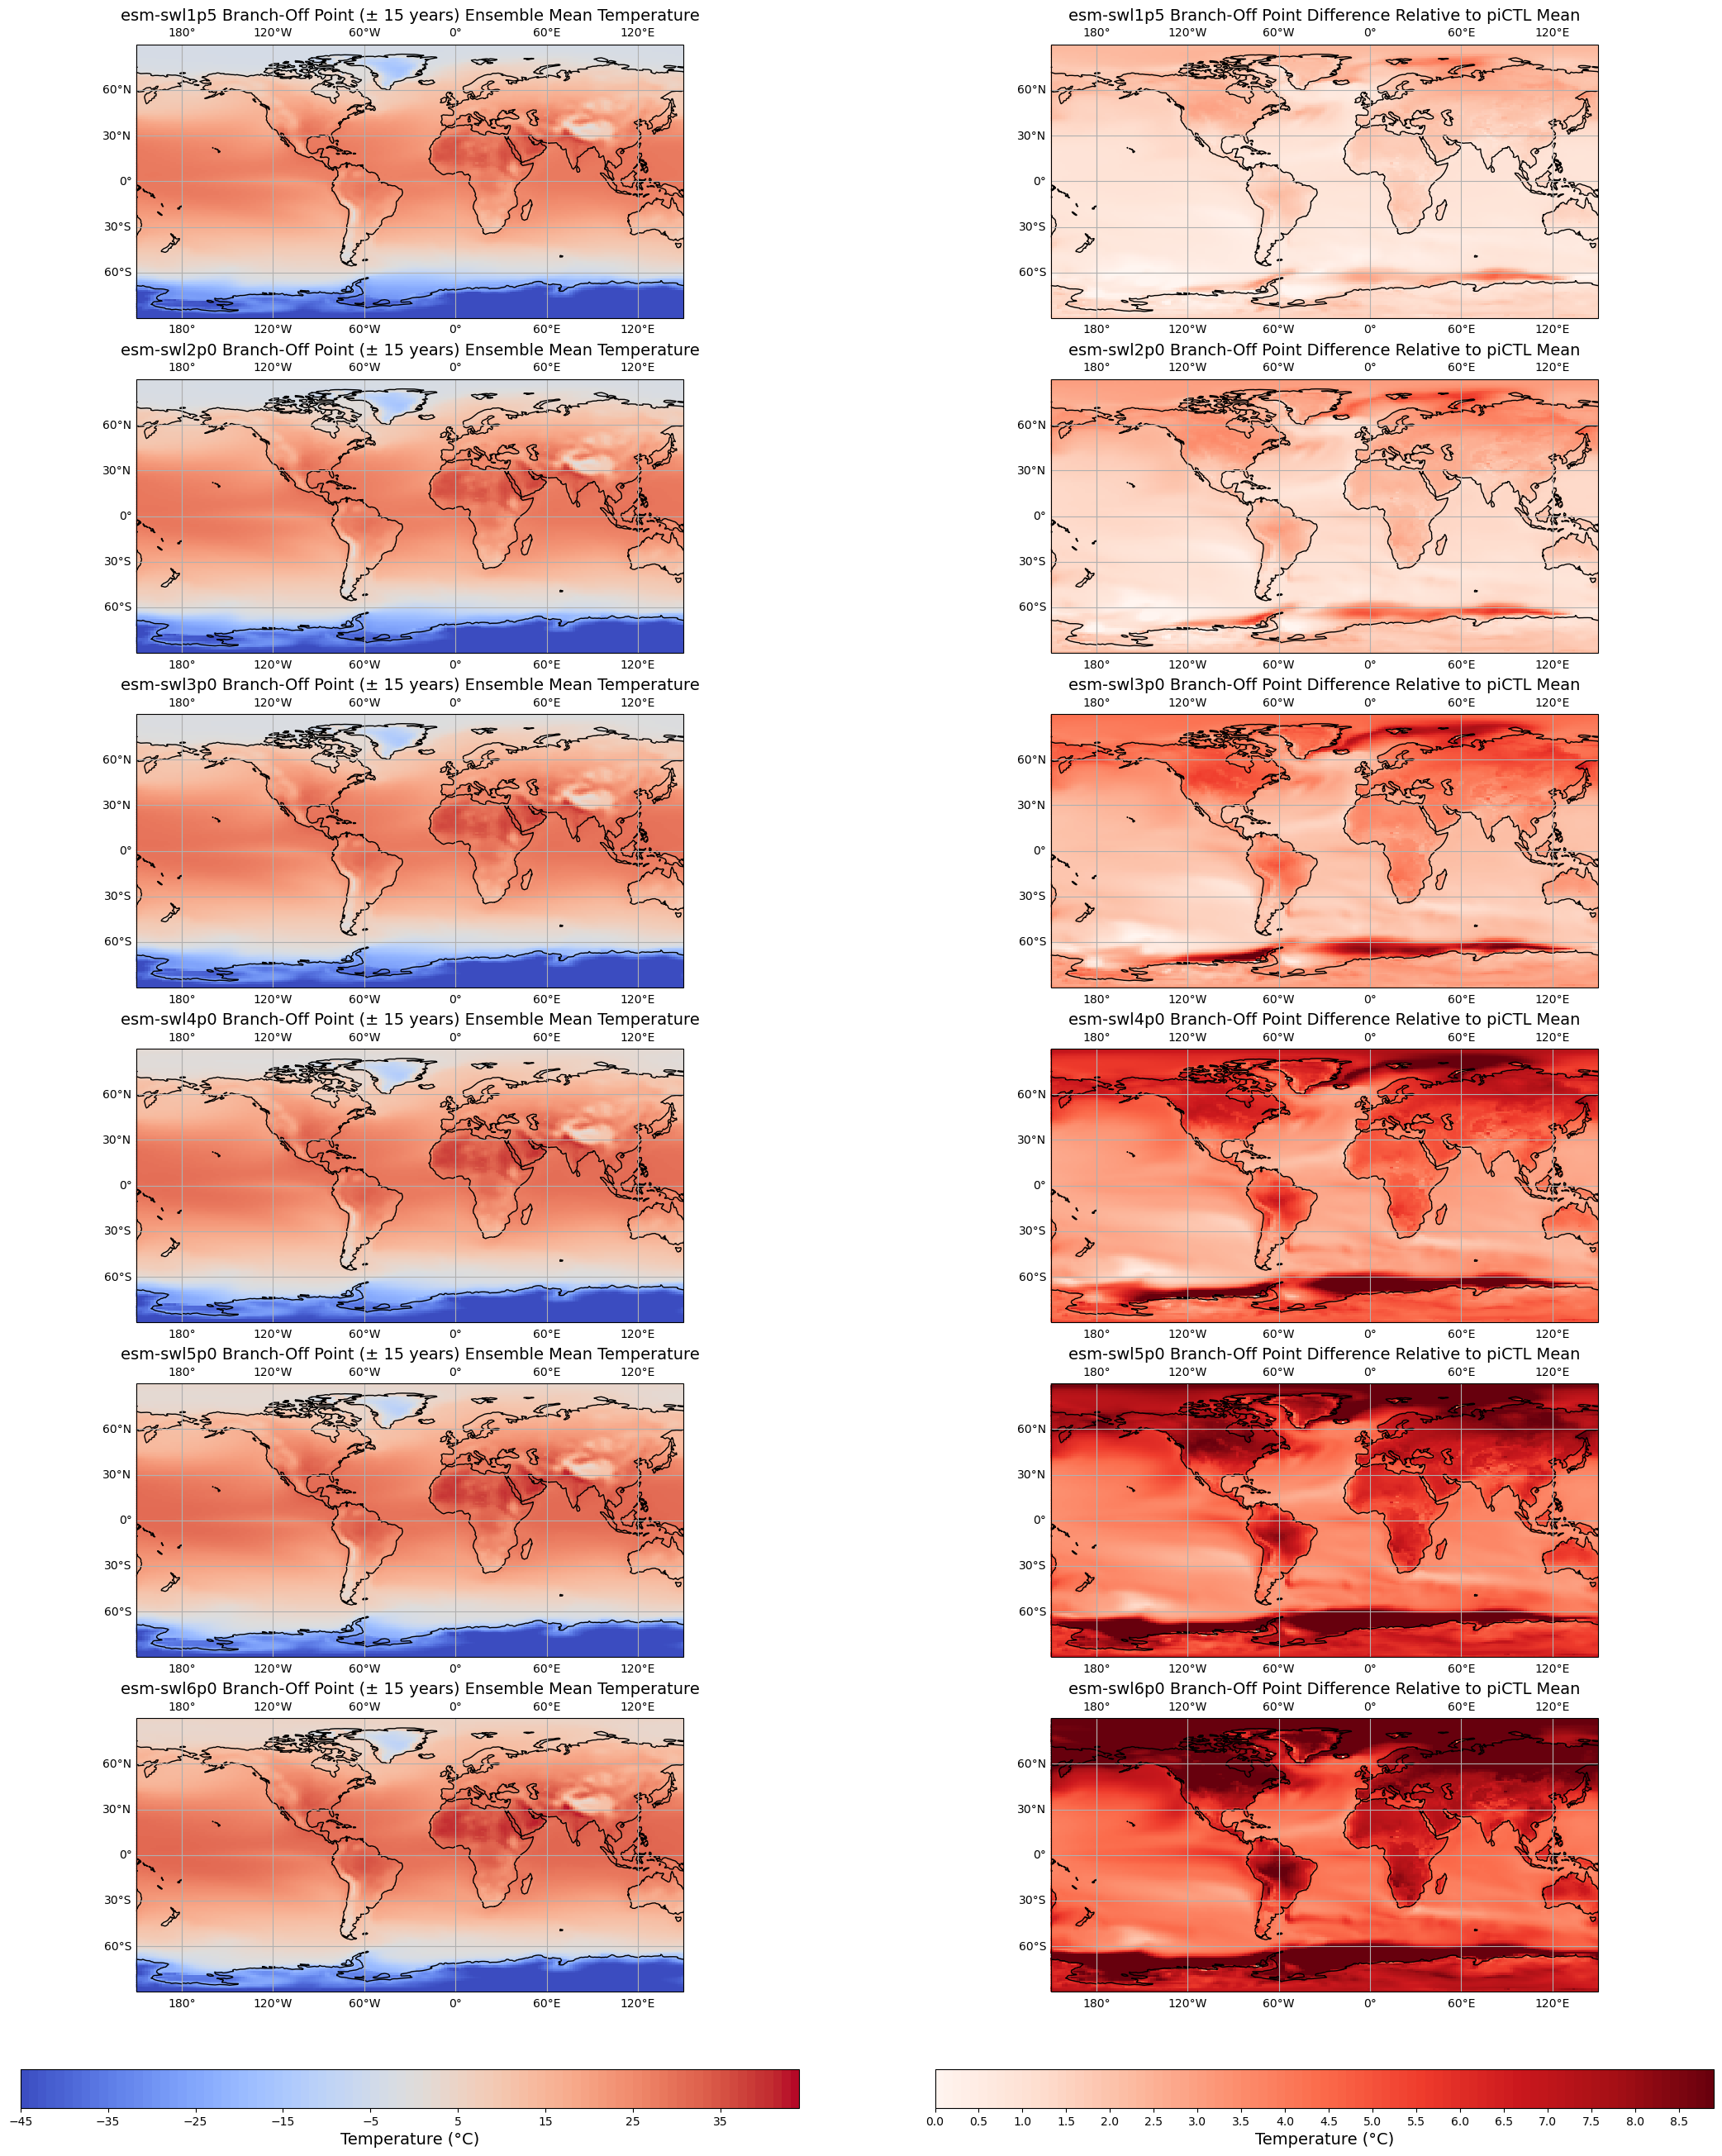

In [53]:
# Colour palette parameters.
vmin_clim = -45
vmax_clim = 45

vmin_anom = 0
vmax_anom = 9

# Extent
lonmin = -180
lonmax = 180
latmin = -90
latmax = 90

cbar_label_clim = 'Temperature (°C)'
cbar_label_anom = 'Temperature (°C)'

filename = f'{path_figure}climatology_difference_branch-off_points.png'

ramp_up_maps(climatology_ens_mean, anomaly_data, level_list, vmin_clim, vmax_clim, vmin_anom, vmax_anom,
             cbar_label_clim, cbar_label_anom, lonmin, lonmax, latmin, latmax, Save=True, filename=filename)

## Net-Zero Run Analysis

### Compute Seasonal Average

In [54]:
# Ramp-Up
seas = 'MJJAS'
members = ['r1i1p1f1']
level_list = ["esm-swl1p5", "esm-swl2p0", "esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

seas_avg_branch_run = {member: {} for member in members}

# Compute seasonal average for every ensemble and scenario
for member in members:
    for scenario in level_list:
        data = level_run_model_1_files[scenario]
        seas_avg_branch_run[member][scenario] = seasonal_average_over_years_customed_MJJAS(data)
        seas_avg_branch_run[member][scenario] -= 273.15

In [55]:
# Data quality check.
seas_avg_branch_run[members[0]][level_list[0]]['tas'].values[:1]

array([[[-56.178116 , -56.16118  , -56.1519   , ..., -56.23378  ,
         -56.40361  , -56.39032  ],
        [-53.587738 , -53.682556 , -53.870407 , ..., -53.273727 ,
         -53.422943 , -53.35634  ],
        [-53.11577  , -53.468796 , -53.67534  , ..., -52.5912   ,
         -52.911957 , -52.951263 ],
        ...,
        [ -2.255371 ,  -2.2435608,  -2.2174683, ...,  -2.296814 ,
          -2.2866516,  -2.2794495],
        [ -2.5003967,  -2.486969 ,  -2.4751892, ...,  -2.5347595,
          -2.5244446,  -2.513916 ],
        [ -2.620453 ,  -2.624176 ,  -2.6212769, ...,  -2.625183 ,
          -2.6229858,  -2.6234436]]], shape=(1, 144, 192), dtype=float32)

### Student t-Test

In [56]:
def ttest_NO_bootstrap(data_scen, data_piCTL):
    n_scen = data_scen.shape[0]
    n_ctl = data_piCTL.shape[0]

    assert n_scen == n_ctl
    
    t_stat, p_value = ttest_ind(data_scen, data_piCTL, axis=0, equal_var=False)

    # Create an Xarray
    p_empirical_xr = xr.DataArray(p_value, dims=["lat", "lon"],
                                  coords={"lat": data_scen.lat, "lon": data_scen.lon},
                                  name="p_value")

    # Assign a name to your DataArray
    p_empirical_xr.name = "p_value"

    # Convert it to a Dataset (NetCDF requires a Dataset format)
    ds = p_empirical_xr.to_dataset()    
    return ds

### Compute Statistical Significance and Anomaly (First-Last 100 Years)

In [57]:
# Dictionary storing p-values for each level.
p_val_dict = {}
gwl_diff_dict = {}

for scenario in level_list:
    # Student-t
    data_gwl = seas_avg_branch_run[member][scenario]
    data_gwl_first100yrs = data_gwl.sel(year=slice(data_gwl['year'][0], data_gwl['year'][99]))
    data_gwl_last100yrs = data_gwl.sel(year=slice(data_gwl['year'][-100], data_gwl['year'][-1]))
    p_val_dict[scenario] = ttest_NO_bootstrap(data_gwl_first100yrs['tas'], data_gwl_last100yrs['tas'])

    # Anomaly
    anomaly = data_gwl_last100yrs.mean('year') - data_gwl_first100yrs.mean('year')
    gwl_diff_dict[scenario] = anomaly

### Implementation 2a (Plot)

In [62]:
def net_zero_maps(diff_data, level_list, vmin, vmax, cbar_label,
                  lonmin, lonmax, latmin, latmax, Save, filename, p_values):

    fig, axes = plt.subplots(2, 3, figsize=(24, 12), 
                             subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-30)}, 
                             constrained_layout=True)

    axes = axes.flatten()

    # Discrete colour levels
    levels = np.arange(vmin, vmax, 0.01)

    for i, scenario in enumerate(level_list):

        data = diff_data[scenario]['tas']

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})

        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})

        data = data.transpose('latitude', 'longitude')

        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)

        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

        contour = axes[i].contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap='OrRd',
                                   extend='neither', transform=ccrs.PlateCarree())

        mm = axes[i].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin, vmax=vmax,
                                   transform=ccrs.PlateCarree(), cmap='OrRd')

        if p_values[scenario]['p_value'] is not None:
        
            # Add cyclic point to p_values using the original lon (not lon_cyclic)
            p_cyclic, _ = add_cyclic_point(p_values[scenario]['p_value'].values, coord=lon_orig, axis=1)
    
            # Compute mask
            sig_mask = p_cyclic <= 0.05
            hatch_mask = np.where(sig_mask, 1, np.nan)
    
            # Overlay hatching
            axes[i].pcolor(lon2d, lat2d, hatch_mask, hatch='..', alpha=0.0, transform=ccrs.PlateCarree(),
                          zorder=1)
        
        axes[i].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i].coastlines()
        axes[i].gridlines(draw_labels=True)

        axes[i].set_title(f'{scenario} Difference: Last 100 Years - First 100 Years',
                          fontsize=14)

    # One shared colourbar for all maps
    cbar = fig.colorbar(contour, ax=axes, orientation='horizontal', fraction=0.04, pad=0.03, 
                        ticks=np.arange(vmin, vmax, 0.1))
    cbar.set_label(cbar_label, fontsize=14)

    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Plot Difference

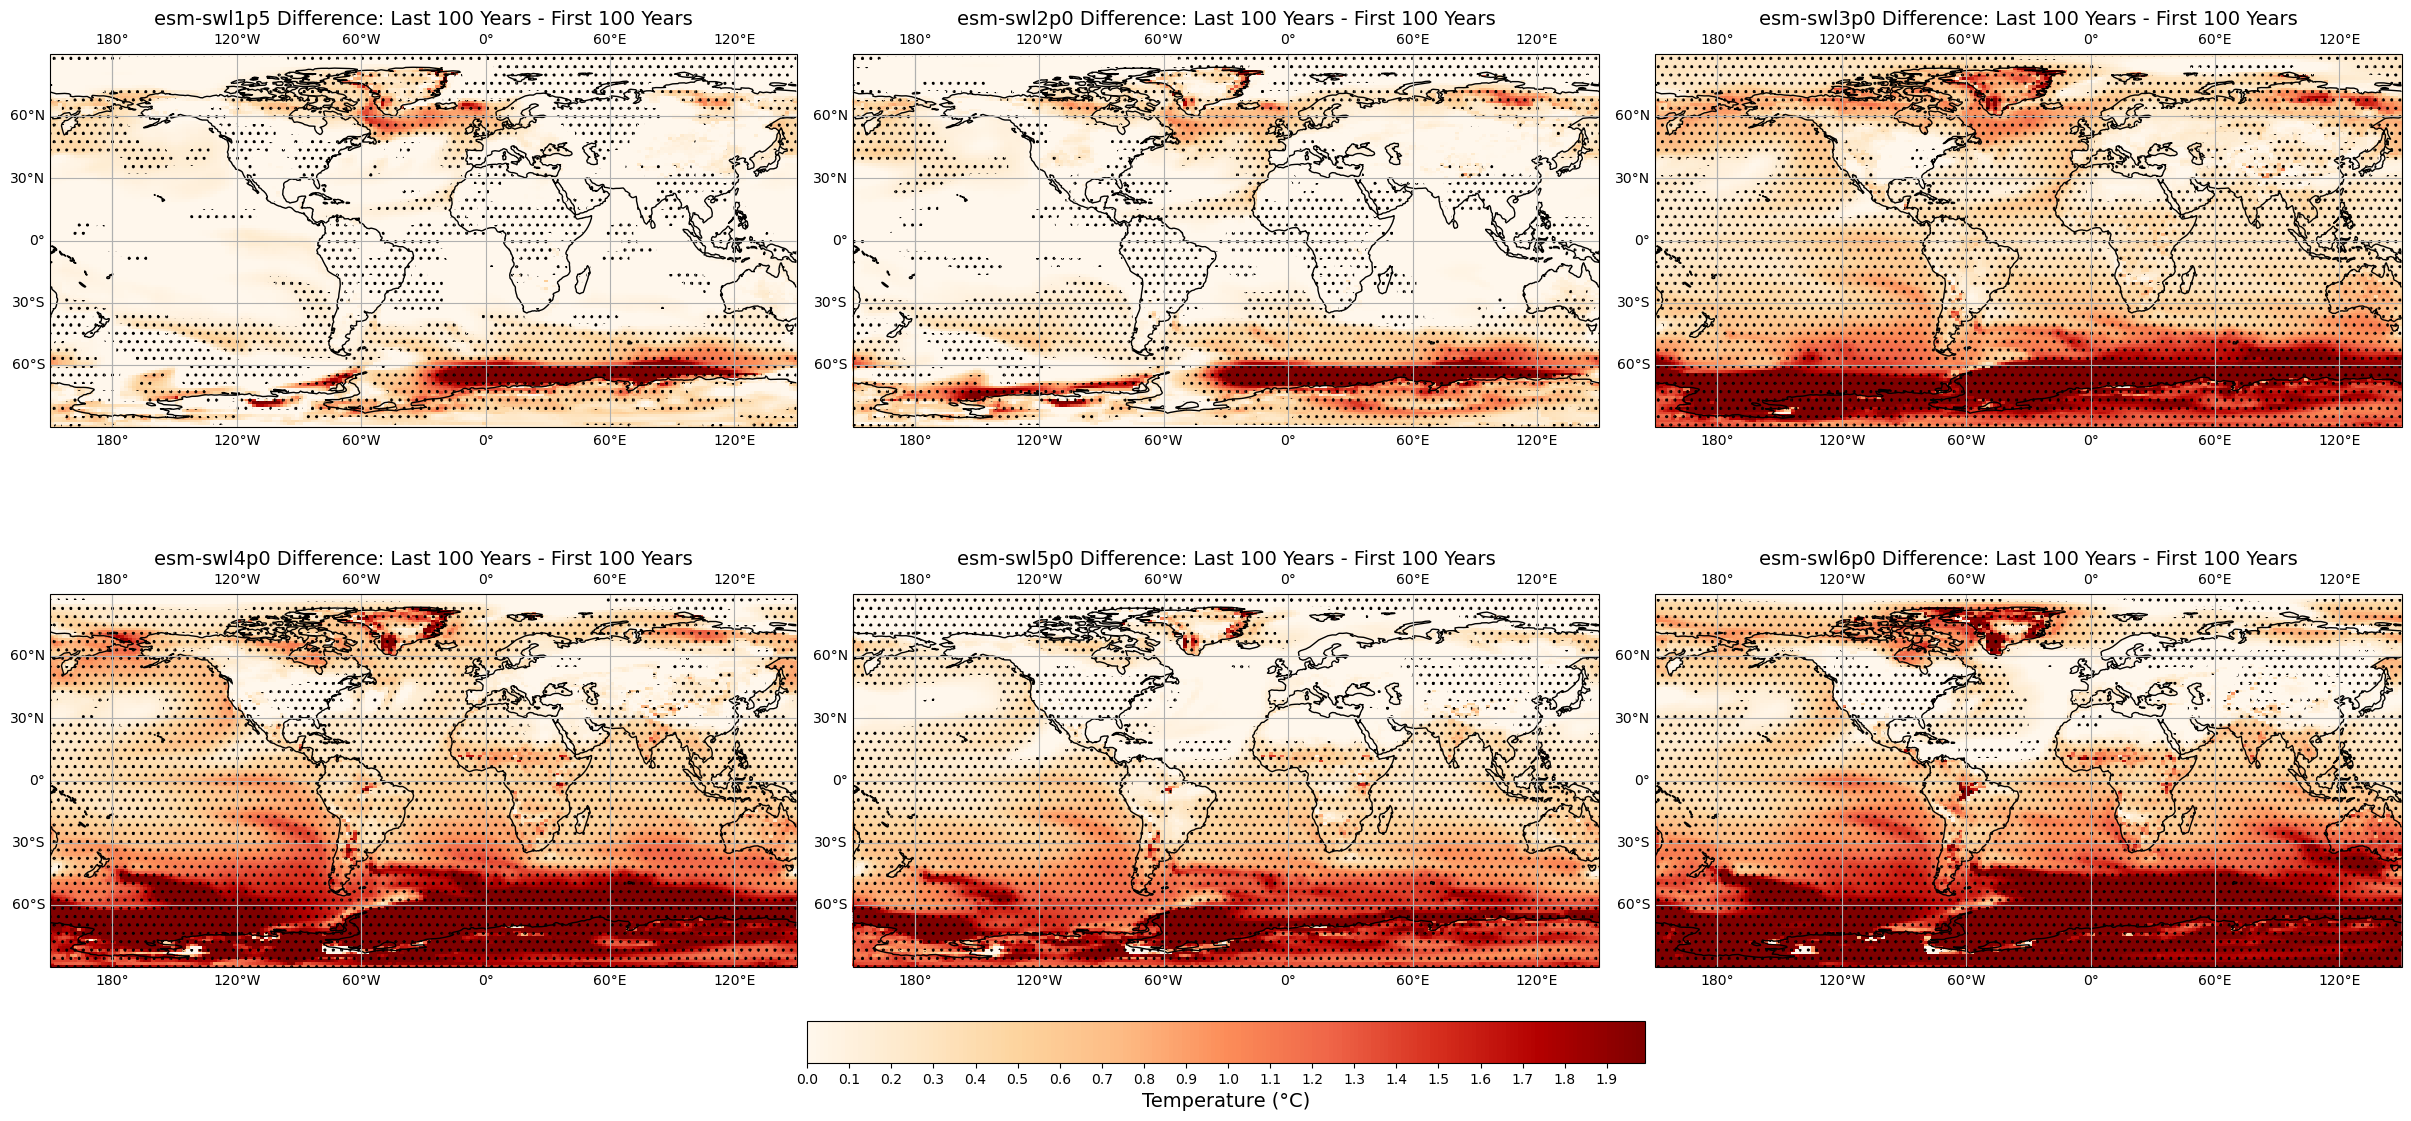

In [63]:
# Colour palette parameters.
vmin = 0
vmax = 2

# Extent
lonmin = -180
lonmax = 180
latmin = -90
latmax = 90

cbar_label = 'Temperature (°C)'
Save = True
filename = f'{path_figure}net_zero_run_diff_map.png'

net_zero_maps(gwl_diff_dict, level_list, vmin, vmax, cbar_label, lonmin, lonmax, latmin, latmax, Save, filename, p_val_dict)

### Define Boxes

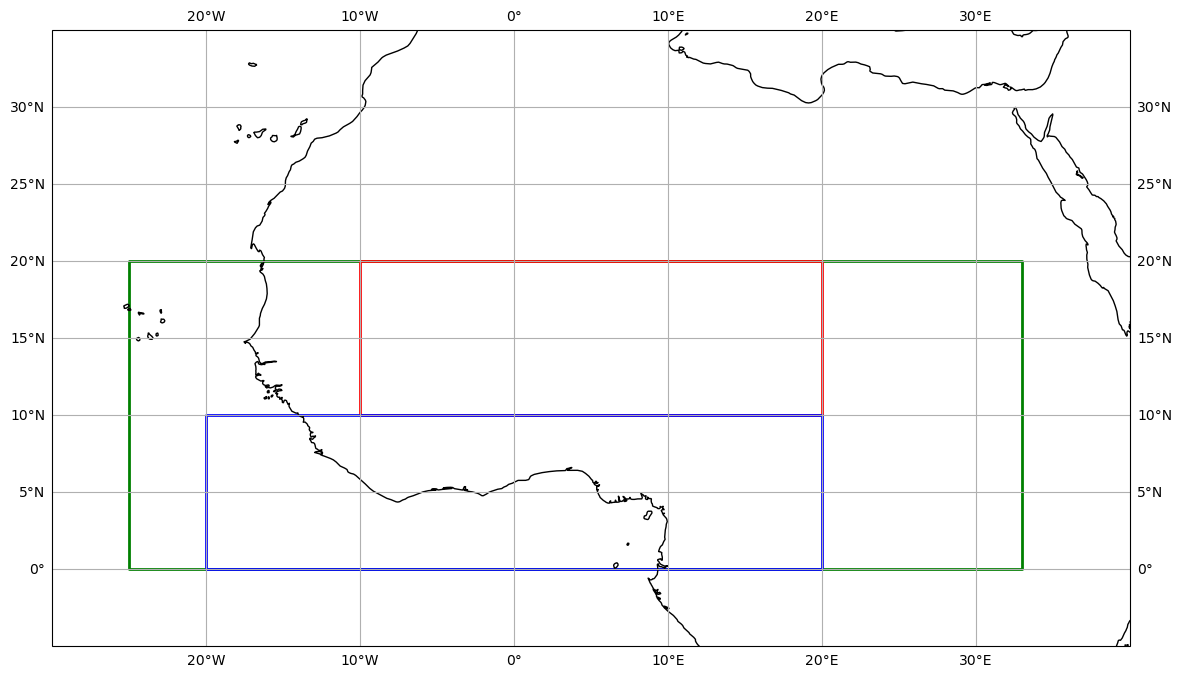

In [33]:
import shapely.geometry as sgeom

def lon360_to_180(lon):
    return ((lon + 180) % 360) - 180

# Define box limits.
# Overview
test_lon_min, test_lon_max = lon360_to_180(335.0), lon360_to_180(33.0)   # degrees
test_lat_min, test_lat_max = 0.0, 20.0                                   # degrees

# Define polygon (anti-clockwise order)
test_poly = sgeom.Polygon([
    (test_lon_min, test_lat_min),  # SW corner
    (test_lon_max, test_lat_min),  # SE corner
    (test_lon_max, test_lat_max),  # NE corner
    (test_lon_min, test_lat_max),  # NW corner
])

# Sahel
sahel_lon_min, sahel_lon_max = lon360_to_180(350.0), lon360_to_180(20.0)   # degrees
sahel_lat_min, sahel_lat_max = 10.0, 20.0                                  # degrees

sahel_poly = sgeom.Polygon([
    (sahel_lon_min, sahel_lat_min),  # SW corner
    (sahel_lon_max, sahel_lat_min),  # SE corner
    (sahel_lon_max, sahel_lat_max),  # NE corner
    (sahel_lon_min, sahel_lat_max),  # NW corner
])

# Mid-coast
# This box requires masking as it lies between the coast and continent.
coast_lon_min, coast_lon_max = lon360_to_180(340.0), lon360_to_180(20.0)   # degrees
coast_lat_min, coast_lat_max = -0.0, 10.0                                  # degrees

coast_poly = sgeom.Polygon([
    (coast_lon_min, coast_lat_min),  # SW corner
    (coast_lon_max, coast_lat_min),  # SE corner
    (coast_lon_max, coast_lat_max),  # NE corner
    (coast_lon_min, coast_lat_max),  # NW corner
])

# Plot map to make sure it is the region we are interested in.
fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_geometries([test_poly], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='green', linewidth=2)
ax.add_geometries([sahel_poly], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='red', linewidth=2)
ax.add_geometries([coast_poly], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=2)

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_extent([-30, 40, -5, 35.0], crs=ccrs.PlateCarree())
plt.savefig('/home/users/alvin_ch/figures/Multi-model/UKESM/Precip/WAM-pr-Regional-Average-Boxes.png', dpi=450)
plt.show();

In [34]:
regions = {"overall": test_poly, "sahel": sahel_poly, "west_coast": coast_poly}

region_colors = {'overall': 'green', 'sahel': 'red', 'west_coast': 'blue'}
region_labels = True

regions_list = ['overall', 'sahel', 'west_coast']
seas_list = ['MJJAS']

In [35]:
def polygon_mask(ds, polygon, lon_name="longitude", lat_name="latitude"):
    """
    Works for 1-D lon and lat (regular grids).
    Produces mask with dims (lat, lon).
    """

    lon = ds[lon_name].values        # shape (192,)
    lat = ds[lat_name].values        # shape (144,)

    # Build 2D coordinate grid
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Check each grid point
    points = [sgeom.Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel())]
    inside = np.array([polygon.covers(pt) for pt in points])

    mask = inside.reshape(lat2d.shape)   # shape (144, 192)

    # Return DataArray with correct dims and coords
    return xr.DataArray(
        mask,
        dims=(ds[lat_name].dims[0], ds[lon_name].dims[0]),
        coords={ds[lat_name].dims[0]: ds[lat_name],
                ds[lon_name].dims[0]: ds[lon_name]}
    )

### Implementation 4a (Weighted Average)

In [36]:
# This implementation is also used in the time series with land-sea mask applied.
def area_weighted_avg_masked(data):
    import numpy as np
    
    # Latitude weights: cosine of lat in radians
    lat_rad = np.radians(data['latitude'])
    lat_weights = np.cos(lat_rad)
    
    # Broadcast lat weights to full spatial dims
    # Assuming data dims: ('time', 'lat', 'lon') or similar
    weights = lat_weights.broadcast_like(data.isel(year=0))
    
    # Create a mask of valid (non-NaN) data points
    valid_mask = ~np.isnan(data)
    
    # Apply mask to weights (weights are zero where data is invalid)
    weights_masked = weights * valid_mask
    
    # Normalize weights so they sum to 1 along spatial dims for each time (or other dims)
    weights_sum = weights_masked.sum(dim=['latitude', 'longitude'])
    
    # Avoid division by zero (where weights_sum == 0)
    weights_sum = weights_sum.where(weights_sum != 0)
    
    # Compute weighted average
    weighted_avg = (data * weights_masked).sum(dim=['latitude', 'longitude']) / weights_sum
    return weighted_avg

### Compute Ensemble Mean

In [37]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='pr'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [38]:
time_series_ens_mean = compute_ensemble_mean(ensemble_members, interpolated_model_files)
time_series_ens_mean

<xarray.DataArray 'pr' (time: 1980, latitude: 72, longitude: 144)> Size: 82MB
dask.array<mean_agg-aggregate, shape=(1980, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 16kB 1850-01-16 00:00:00 ... 2014-12-16 00:00:00
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75